# 2. Feature Engineering

Feature engineering is the process of preparing and transforming raw data into meaningful features that can be used by machine learning models.

In this notebook, we will prepare the flight dataset for the flight price prediction model.

## Define Features and Target

The objective of this model is to predict the price of a flight.

The target variable is `price`, while the remaining selected columns will be considered as potential input features.

## 2.1 Load the Flight Dataset

We load the flight dataset and inspect its structure before selecting the features and target variable.

In [48]:
%pip install xgboost optuna

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
# For Data Manipulation
import pandas as pd
import numpy as np

# For Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train test split and cross validation
from sklearn.model_selection import (train_test_split, cross_val_score)

#Preprocessing
from sklearn.preprocessing import StandardScaler

#Pipelines
from sklearn.pipeline import Pipeline

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso 
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# For Hyperparameter tuning
import optuna

# Model evaluation
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score)

#Display warnings
import warnings
warnings.filterwarnings('ignore')

print("Requiremets imported successfully")

Requiremets imported successfully


In [50]:
flights = pd.read_csv("../data/raw/flights.csv")

flights.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


## 2.2 Inspect Dataset Structure

We inspect the columns, data types, and number of records to understand the data that will be used for feature engineering.

In [51]:
flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  str    
 3   to          271888 non-null  str    
 4   flightType  271888 non-null  str    
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  str    
 9   date        271888 non-null  str    
dtypes: float64(3), int64(2), str(5)
memory usage: 20.7 MB


In [52]:
flights.shape

(271888, 10)

## 2.3 Remove Unnecessary Columns

The `travelCode` and `userCode` columns are identifiers and do not provide meaningful information for predicting flight prices.

The `date` column is also removed because the EDA showed very little variation in average flight prices across months and days of the week.

We retain the remaining variables because they may contain useful information for predicting flight prices.

In [53]:
flights['date'].dtype

<StringDtype(storage='python', na_value=nan)>

In [54]:
flights['date'] = pd.to_datetime(flights['date'])
flights['date'].dtype

dtype('<M8[us]')

In [55]:
flights['day'] = flights['date'].dt.day
flights['month'] = flights['date'].dt.month
flights['year'] = flights['date'].dt.year

In [56]:
flights['day_name'] = flights['date'].dt.day_name()
flights[['date', 'day', 'month', 'year', 'day_name']].head()

,date,day,month,year,day_name
0,2019-09-26,26,9,2019,Thursday
1,2019-09-30,30,9,2019,Monday
2,2019-10-03,3,10,2019,Thursday
3,2019-10-04,4,10,2019,Friday
4,2019-10-10,10,10,2019,Thursday


In [57]:
price_by_year = flights.groupby('year')['price'].agg(Average_price = 'mean', 
                                                     Minimum_price = 'min',
                                                     Maximumu_price = 'max').round(2).reset_index()

price_by_year

,year,Average_price,Minimum_price,Maximumu_price
0,2019,952.50,301.51,1754.17
1,2020,956.73,301.51,1754.17
2,2021,957.20,301.51,1754.17
3,2022,963.09,301.51,1754.17
4,2023,960.78,301.51,1754.17


### 2.4 Remove Uninformative Date Features

EDA showed that flight prices have very little variation across months, days of the week, and years. Therefore, these date-based features are unlikely to provide meaningful predictive information.

The original `date` column and the derived date features will be removed from the modelling dataset.

In [58]:
flights = flights.drop(
    columns=['date', 'day', 'month', 'year', 'day_name']
)

In [59]:
flights = flights.drop(columns=['travelCode', 'userCode'])

In [60]:
flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   from        271888 non-null  str    
 1   to          271888 non-null  str    
 2   flightType  271888 non-null  str    
 3   price       271888 non-null  float64
 4   time        271888 non-null  float64
 5   distance    271888 non-null  float64
 6   agency      271888 non-null  str    
dtypes: float64(3), str(4)
memory usage: 14.5 MB


### 2.5 Flight Duration Feature

The `time` column represents flight duration and is a numerical feature.

EDA showed a positive relationship between flight duration and flight price. Therefore, the original numerical `time` feature will be retained for modelling rather than converting it into broad categories.

In [61]:
flights['time'].describe()

count    271888.000000
mean          1.421147
std           0.542541
min           0.440000
25%           1.040000
50%           1.460000
75%           1.760000
max           2.440000
Name: time, dtype: float64

### 2.7 Distance Feature

The `distance` column represents the flight distance and is a numerical feature.

EDA showed that flight price tends to increase as distance increases. Therefore, `distance` will be retained as a numerical feature for modelling.

In [62]:
flights['distance'].describe()

count    271888.000000
mean        546.955535
std         208.851288
min         168.220000
25%         401.660000
50%         562.140000
75%         676.530000
max         937.770000
Name: distance, dtype: float64

## 2.8 Flight Type Feature

`flightType` is a categorical feature representing the class of travel.

EDA showed noticeable differences in flight prices across flight types, so this feature is expected to be useful for predicting flight prices.

Before encoding, we will inspect its categories and frequency distribution.

In [63]:
flights['flightType'].value_counts()

flightType
firstClass    116418
premium        78004
economic       77466
Name: count, dtype: int64

**Observation:** `flightType` contains three well-represented categories: firstClass (116,418), premium (78,004), and economic (77,466). Since these categories have no inherent numerical order, one-hot encoding will be used instead of label encoding.

### 2.9 One-Hot Encoding of Flight Type

Since `flightType` is a nominal categorical feature with three categories, we will convert it into binary indicator columns using one-hot encoding.

This allows the machine learning model to use the categorical information without imposing an artificial numerical order.

In [64]:
flight_type_encoded = pd.get_dummies(flights['flightType'],
                                     prefix= 'flightType',
                                     dtype = int)

flight_type_encoded

,flightType_economic,flightType_firstClass,flightType_premium
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0
...,...,...,...
271883,0,1,0
271884,1,0,0
271885,1,0,0
271886,1,0,0


In [65]:
flights = pd.concat([flights, flight_type_encoded], axis = 1)
flights.head()

,from,to,flightType,price,time,distance,agency,flightType_economic,flightType_firstClass,flightType_premium
0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,0,1,0
1,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,0,1,0
2,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,0,1,0
3,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,0,1,0
4,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,0,1,0


In [66]:
flights[['flightType',
         'flightType_economic',
         'flightType_firstClass',
         'flightType_premium']].head(10)

,flightType,flightType_economic,flightType_firstClass,flightType_premium
0,firstClass,0,1,0
1,firstClass,0,1,0
2,firstClass,0,1,0
3,firstClass,0,1,0
4,firstClass,0,1,0
5,firstClass,0,1,0
6,economic,1,0,0
7,economic,1,0,0
8,economic,1,0,0
9,economic,1,0,0


In [67]:
flights = flights.loc[:, ~flights.columns.duplicated()]

In [68]:
flights.columns

Index(['from', 'to', 'flightType', 'price', 'time', 'distance', 'agency',
       'flightType_economic', 'flightType_firstClass', 'flightType_premium'],
      dtype='str')

### 2.10 Remove Original Flight Type Column

The `flightType` column has been successfully converted into three binary features through one-hot encoding.

The original categorical column is no longer required and will be removed to avoid keeping duplicate representations of the same information.

In [69]:
flights = flights.drop(columns=['flightType'])

### 2.11 Agency Feature

`agency` represents the airline/agency associated with each flight.

Since it is a categorical feature, we will first examine its categories and their frequencies before deciding how to encode it.

In [70]:
flights['agency'].value_counts()

agency
Rainbow        116752
CloudFy        116378
FlyingDrops     38758
Name: count, dtype: int64

**Observation:** `agency` contains three categories: Rainbow (116,752), CloudFy (116,378), and FlyingDrops (38,758). All categories have sufficient observations, so `agency` will be retained and one-hot encoded for modelling.

In [71]:
agency_encoded = pd.get_dummies(flights['agency'],
                                prefix = 'agency',
                                dtype =int)

agency_encoded.head()

,agency_CloudFy,agency_FlyingDrops,agency_Rainbow
0,0,1,0
1,0,1,0
2,1,0,0
3,1,0,0
4,1,0,0


In [72]:
flights = pd.concat([flights, agency_encoded], axis = 1)
flights.head()

,from,to,price,time,distance,agency,flightType_economic,flightType_firstClass,flightType_premium,agency_CloudFy,agency_FlyingDrops,agency_Rainbow
0,Recife (PE),Florianopolis (SC),1434.38,1.76,676.53,FlyingDrops,0,1,0,0,1,0
1,Florianopolis (SC),Recife (PE),1292.29,1.76,676.53,FlyingDrops,0,1,0,0,1,0
2,Brasilia (DF),Florianopolis (SC),1487.52,1.66,637.56,CloudFy,0,1,0,1,0,0
3,Florianopolis (SC),Brasilia (DF),1127.36,1.66,637.56,CloudFy,0,1,0,1,0,0
4,Aracaju (SE),Salvador (BH),1684.05,2.16,830.86,CloudFy,0,1,0,1,0,0


### 2.12 Remove Original Agency Column

The `agency` column has been successfully one-hot encoded into three binary features.

The original categorical column is removed because its information is now represented by the encoded columns.

In [73]:
flights = flights.drop(columns = ['agency'])

In [74]:
flights.columns

Index(['from', 'to', 'price', 'time', 'distance', 'flightType_economic',
       'flightType_firstClass', 'flightType_premium', 'agency_CloudFy',
       'agency_FlyingDrops', 'agency_Rainbow'],
      dtype='str')

### 2.13 Departure Location (`from`)

The `from` column represents the departure location of each flight.

Before choosing an encoding method, we will inspect the number of unique locations and their frequency distribution.

In [75]:
flights['from'].value_counts()

from
Florianopolis (SC)     57317
Aracaju (SE)           37224
Campo Grande (MS)      34748
Brasilia (DF)          30779
Recife (PE)            30480
Natal (RN)             23796
Sao Paulo (SP)         23625
Salvador (BH)          17104
Rio de Janeiro (RJ)    16815
Name: count, dtype: int64

**Observation:** The `from` feature contains 9 departure locations, with Florianopolis (SC) having the highest number of flights (57,317) and Rio de Janeiro (RJ) the lowest (16,815). All locations have sufficient observations, so `from` will be retained and one-hot encoded for modelling.

In [76]:
from_encoded = pd.get_dummies(flights['from'],
                              prefix = 'from',
                              dtype = int)

from_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 9 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   from_Aracaju (SE)         271888 non-null  int64
 1   from_Brasilia (DF)        271888 non-null  int64
 2   from_Campo Grande (MS)    271888 non-null  int64
 3   from_Florianopolis (SC)   271888 non-null  int64
 4   from_Natal (RN)           271888 non-null  int64
 5   from_Recife (PE)          271888 non-null  int64
 6   from_Rio de Janeiro (RJ)  271888 non-null  int64
 7   from_Salvador (BH)        271888 non-null  int64
 8   from_Sao Paulo (SP)       271888 non-null  int64
dtypes: int64(9)
memory usage: 18.7 MB


In [77]:
from_encoded.head()

,from_Aracaju (SE),from_Brasilia (DF),from_Campo Grande (MS),from_Florianopolis (SC),from_Natal (RN),from_Recife (PE),from_Rio de Janeiro (RJ),from_Salvador (BH),from_Sao Paulo (SP)
0,0,0,0,0,0,1,0,0,0
1,0,0,0,1,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0


In [78]:
flights = pd.concat([flights, from_encoded], axis = 1)
flights.columns

Index(['from', 'to', 'price', 'time', 'distance', 'flightType_economic',
       'flightType_firstClass', 'flightType_premium', 'agency_CloudFy',
       'agency_FlyingDrops', 'agency_Rainbow', 'from_Aracaju (SE)',
       'from_Brasilia (DF)', 'from_Campo Grande (MS)',
       'from_Florianopolis (SC)', 'from_Natal (RN)', 'from_Recife (PE)',
       'from_Rio de Janeiro (RJ)', 'from_Salvador (BH)',
       'from_Sao Paulo (SP)'],
      dtype='str')

In [79]:
flights['to'].value_counts()

to
Florianopolis (SC)     57317
Aracaju (SE)           37224
Campo Grande (MS)      34748
Brasilia (DF)          30779
Recife (PE)            30480
Natal (RN)             23796
Sao Paulo (SP)         23625
Salvador (BH)          17104
Rio de Janeiro (RJ)    16815
Name: count, dtype: int64

In [80]:
to_encoded = pd.get_dummies(flights['to'],
                            prefix = 'to',
                            dtype = int)

to_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   to_Aracaju (SE)         271888 non-null  int64
 1   to_Brasilia (DF)        271888 non-null  int64
 2   to_Campo Grande (MS)    271888 non-null  int64
 3   to_Florianopolis (SC)   271888 non-null  int64
 4   to_Natal (RN)           271888 non-null  int64
 5   to_Recife (PE)          271888 non-null  int64
 6   to_Rio de Janeiro (RJ)  271888 non-null  int64
 7   to_Salvador (BH)        271888 non-null  int64
 8   to_Sao Paulo (SP)       271888 non-null  int64
dtypes: int64(9)
memory usage: 18.7 MB


In [81]:
flights = pd.concat([flights, to_encoded], axis = 1)
flights.columns

Index(['from', 'to', 'price', 'time', 'distance', 'flightType_economic',
       'flightType_firstClass', 'flightType_premium', 'agency_CloudFy',
       'agency_FlyingDrops', 'agency_Rainbow', 'from_Aracaju (SE)',
       'from_Brasilia (DF)', 'from_Campo Grande (MS)',
       'from_Florianopolis (SC)', 'from_Natal (RN)', 'from_Recife (PE)',
       'from_Rio de Janeiro (RJ)', 'from_Salvador (BH)', 'from_Sao Paulo (SP)',
       'to_Aracaju (SE)', 'to_Brasilia (DF)', 'to_Campo Grande (MS)',
       'to_Florianopolis (SC)', 'to_Natal (RN)', 'to_Recife (PE)',
       'to_Rio de Janeiro (RJ)', 'to_Salvador (BH)', 'to_Sao Paulo (SP)'],
      dtype='str')

In [82]:
flights = flights.drop(columns=['from', 'to'])

In [83]:
flights.columns

Index(['price', 'time', 'distance', 'flightType_economic',
       'flightType_firstClass', 'flightType_premium', 'agency_CloudFy',
       'agency_FlyingDrops', 'agency_Rainbow', 'from_Aracaju (SE)',
       'from_Brasilia (DF)', 'from_Campo Grande (MS)',
       'from_Florianopolis (SC)', 'from_Natal (RN)', 'from_Recife (PE)',
       'from_Rio de Janeiro (RJ)', 'from_Salvador (BH)', 'from_Sao Paulo (SP)',
       'to_Aracaju (SE)', 'to_Brasilia (DF)', 'to_Campo Grande (MS)',
       'to_Florianopolis (SC)', 'to_Natal (RN)', 'to_Recife (PE)',
       'to_Rio de Janeiro (RJ)', 'to_Salvador (BH)', 'to_Sao Paulo (SP)'],
      dtype='str')

## 2.16 Final Data Quality Check

Before preparing the data for modelling, we will check for missing values in all remaining features.

Since the dataset has already undergone feature engineering, this check ensures that no missing values were introduced during the transformation process.

In [84]:
flights.isnull().sum()

price                       0
time                        0
distance                    0
flightType_economic         0
flightType_firstClass       0
flightType_premium          0
agency_CloudFy              0
agency_FlyingDrops          0
agency_Rainbow              0
from_Aracaju (SE)           0
from_Brasilia (DF)          0
from_Campo Grande (MS)      0
from_Florianopolis (SC)     0
from_Natal (RN)             0
from_Recife (PE)            0
from_Rio de Janeiro (RJ)    0
from_Salvador (BH)          0
from_Sao Paulo (SP)         0
to_Aracaju (SE)             0
to_Brasilia (DF)            0
to_Campo Grande (MS)        0
to_Florianopolis (SC)       0
to_Natal (RN)               0
to_Recife (PE)              0
to_Rio de Janeiro (RJ)      0
to_Salvador (BH)            0
to_Sao Paulo (SP)           0
dtype: int64

In [85]:
flights.isnull().sum().sum()

np.int64(0)

In [86]:
flights.to_csv(
    '../data/processed/flights_feature_engineered.csv',
    index=False
)

In [87]:
import os

os.path.exists('../data/processed/flights_feature_engineered.csv')

True

**Observation:** No missing values are present in the feature-engineered dataset. Therefore, no missing-value treatment is required before model preparation.

## 3. Model Preparation

Before training machine learning models, the dataset needs to be prepared in a way that allows us to evaluate model performance reliably.

In this section, we will:

1. Separate the target variable from the predictor variables.
2. Identify repeated feature combinations in the dataset.
3. Create groups based on unique feature combinations.
4. Perform a group-based train-test split to prevent data leakage.
5. Verify that no feature group is shared between the training and testing datasets.
6. Prepare the data for model training and evaluation.

The main objective is to ensure that the model is evaluated on genuinely unseen feature combinations.

### 3.1 Separating Features and Target

The `price` column is our target variable because the objective of this project is to predict the flight price.

All remaining columns are treated as predictor variables, also known as features.

- **X** → Independent variables/features used by the model for prediction.
- **y** → Dependent variable/target that the model needs to predict.

Separating the target from the features ensures that the model receives only the information that is available for making predictions and does not directly use the target variable as an input.

In [121]:
y = flights['price']
X = flights.drop(columns = ['price'])

In [122]:
X.shape, y.shape

((271888, 26), (271888,))

### 3.2 Identifying Repeated Feature Combinations

Before splitting the data, we investigate whether identical feature combinations occur multiple times.

During the earlier data analysis, we found that a very large proportion of the dataset contains duplicate feature rows. Approximately 99.82% of the feature rows are duplicates.

We also verified that every identical feature combination is associated with exactly one unique flight price.

This is important because a conventional random row-level train-test split could place identical feature combinations in both the training and testing datasets.

In that situation, the model may effectively see the same observation during training and testing, resulting in an overly optimistic evaluation.

To prevent this, we treat each unique combination of features as a separate group.

In [115]:
feature_cols = [col for col in flights.columns if col != 'price']

groups = flights[feature_cols].astype(str).agg('_'.join, axis=1)

> **Important Validation Note:**  
> An initial Random Forest model trained using a conventional row-level train-test split produced an unrealistically perfect R² score of 1.00. Further investigation showed that 99.82% of the feature rows were duplicates and that identical feature combinations were associated with a single price. This indicated that identical feature groups could be present in both the training and testing datasets. To obtain a more realistic estimate of model generalization, a group-based train-test split was adopted.

### 3.3 Group-Based Train-Test Split

A conventional `train_test_split()` randomly divides individual rows between the training and testing datasets.

However, because our dataset contains a very large number of repeated feature combinations, a row-level split could result in the same feature combination appearing in both datasets.

To avoid this potential data leakage, we use `GroupShuffleSplit`.

With `GroupShuffleSplit`, all rows belonging to the same feature group are kept together. Therefore, a particular feature combination can belong to either the training dataset or the testing dataset, but not both.

We use:

- **80%** of the data approximately for training.
- **20%** approximately for testing.
- `random_state=42` to make the split reproducible.

The purpose of this split is to evaluate how well the models generalize to feature combinations that were not seen during training.

In [117]:
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        flights[feature_cols],
        flights['price'],
        groups=groups
    )
)

### 3.4 Creating Training and Testing Datasets

The group-based split returns the row indices belonging to the training and testing datasets.

These indices are used to create:

- `X_train` — features used for model training.
- `X_test` — unseen features used for model evaluation.
- `y_train` — target prices corresponding to the training features.
- `y_test` — target prices corresponding to the testing features.

The resulting datasets will be used consistently across all models so that every model is evaluated on exactly the same observations.

In [118]:
X_train = flights[feature_cols].iloc[train_idx]
X_test = flights[feature_cols].iloc[test_idx]

y_train = flights['price'].iloc[train_idx]
y_test = flights['price'].iloc[test_idx]

### 3.5 Verifying the Train-Test Split

After performing the group-based split, we verify that no feature group is shared between the training and testing datasets.

This is an important validation step because the purpose of using `GroupShuffleSplit` is to ensure that identical feature combinations cannot appear in both datasets.

We compare the groups present in the training and testing sets.

The intersection between these two sets should be zero.

A result of `0` confirms that there are no overlapping feature groups between the training and testing datasets.

In [ ]:
train_groups = set(groups.iloc[train_idx])
test_groups = set(groups.iloc[test_idx])
    
len(train_groups.intersection(test_groups))

0

### 3.6 Final Train-Test Dimensions

Finally, we check the dimensions of the training and testing datasets to confirm that the split was performed correctly.

The resulting datasets contain:

- **221,394 training observations**
- **50,494 testing observations**
- **26 predictor variables**

Because the split is group-based rather than row-based, the training and testing proportions may not be exactly 80:20. This is expected because complete groups must remain together.

In [120]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((221394, 26), (50494, 26), (221394,), (50494,))

## 4. Model Selection

With the dataset now divided using a leakage-aware group-based train-test split, we can begin model selection.

We will initially train several regression algorithms using their baseline configurations and evaluate their performance using the same training and testing datasets.

The initial models include:

1. Linear Regression
2. Ridge Regression
3. Random Forest Regression
4. Gradient Boosting Regression
5. XGBoost Regression

The initial comparison will help us understand how different modelling approaches perform before hyperparameter optimization.

The models will be evaluated using:

- **MAE (Mean Absolute Error)** — measures the average absolute difference between actual and predicted prices. Lower values are better.
- **RMSE (Root Mean Squared Error)** — penalizes larger prediction errors more strongly. Lower values are better.
- **R² Score** — measures the proportion of variance in flight prices explained by the model. Higher values are better.

After the baseline comparison, the strongest candidate models will be considered for hyperparameter optimization using Optuna.

### 4.1 Linear Regression

Linear Regression is used as the first baseline model for predicting flight prices.

It establishes a simple benchmark against which more complex machine learning models can be compared.

StandardScaler is applied within a Pipeline because the numerical features have different scales. Using a Pipeline ensures that the scaler is fitted only on the training data and the same transformation is consistently applied to unseen data.

In [123]:
# Creating the Pipeline for Linear Regression Model
lr_pipeline = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])

# Training the model
lr_pipeline.fit(X_train, y_train)

# Making prediction
y_pred_lr = lr_pipeline.predict(X_test)

In [124]:
mae_linear = mean_absolute_error(y_test, y_pred_lr)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_linear = r2_score(y_test, y_pred_lr)

print(f"mae: {mae_linear}")
print(f"rmse: {rmse_linear}")
print(f"r2_score: {r2_linear}")

mae: 106.8618691895884
rmse: 126.24765106068457
r2_score: 0.9114423850811674


### 4.2 Ridge Regression

Ridge Regression is used as the second linear model for flight price prediction.

Unlike ordinary Linear Regression, Ridge applies L2 regularization to reduce the magnitude of model coefficients and help control overfitting.

StandardScaler is used within a Pipeline because Ridge is sensitive to feature scale. The scaler is fitted only on the training data and then applied to the test data.

In [125]:
# Creating the pipeline for Ridge Regression Model
rg_pipeline = Pipeline([('scaler', StandardScaler()), ('model', Ridge())])

# Training the model
rg_pipeline.fit(X_train, y_train)

y_pred_rg = rg_pipeline.predict(X_test)

In [126]:
mae_ridge = mean_absolute_error(y_test, y_pred_rg)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_rg))
r2_ridge = r2_score(y_test, y_pred_rg)

print(f"mae : {mae_ridge}")
print(f"rmse : {rmse_ridge}")
print(f"r2_score : {r2_ridge}")

mae : 106.92910993712523
rmse : 126.29102372832604
r2_score : 0.9113815262888584


In [127]:
model_results = pd.DataFrame([{'model' : 'Linear Regression',
                               'MAE' : mae_linear,
                               'RMSE' : rmse_linear,
                               'R2_Score' : r2_linear}])

model_results

,model,MAE,RMSE,R2_Score
0,Linear Regression,106.861869,126.247651,0.911442


In [128]:
model_results = pd.concat([model_results, pd.DataFrame([{'model' : 'Ridge Regression',
                                                         'MAE' : mae_ridge,
                                                         'RMSE' : rmse_ridge,
                                                         'R2_Score' : r2_ridge}])])

model_results

,model,MAE,RMSE,R2_Score
0,Linear Regression,106.861869,126.247651,0.911442
0,Ridge Regression,106.929110,126.291024,0.911382


### 4.3 Random Forest Regression

Random Forest Regression is used as a tree-based ensemble model to capture non-linear relationships between the features and flight price.

Unlike linear models, Random Forest does not require feature scaling because tree-based algorithms are not sensitive to the numerical scale of input features.

The initial model is trained using default hyperparameters, while hyperparameter optimization will be performed later using Optuna.

In [129]:
rf = RandomForestRegressor(n_estimators= 100,
                           random_state = 42,
                           n_jobs = 1)

rf.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"ma

In [130]:
# Making prediction
y_pred_rf = rf.predict(X_test)

In [131]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE : {mae_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"R2_Score : {r2_rf:.2f}")

MAE : 72.50
RMSE : 102.02
R2_Score : 0.94


In [132]:
model_results_rf =  pd.DataFrame([{'model' : 'Random Forest',
                                   'MAE' : mae_rf,
                                    'RMSE' : rmse_rf,
                                    'R2_Score' : r2_rf}])

model_results_rf

,model,MAE,RMSE,R2_Score
0,Random Forest,72.497901,102.017274,0.942174


In [133]:
model_results = pd.concat([model_results, model_results_rf], ignore_index = True)

In [134]:
model_results

,model,MAE,RMSE,R2_Score
0,Linear Regression,106.861869,126.247651,0.911442
1,Ridge Regression,106.929110,126.291024,0.911382
2,Random Forest,72.497901,102.017274,0.942174


### 4.4 XGBoost Regression

XGBoost (Extreme Gradient Boosting) is an optimized gradient boosting algorithm based on decision trees.

Similar to other boosting methods, XGBoost builds trees sequentially, where each new tree attempts to reduce the errors made by the existing ensemble. However, XGBoost includes several optimization and regularization techniques that make it powerful for structured/tabular datasets.

We include XGBoost in our model selection because our dataset contains a large number of observations and non-linear relationships between flight characteristics and price.

At this stage, we use the baseline configuration without hyperparameter optimization. Hyperparameter tuning will be performed later using Optuna.

The model will be trained and evaluated using the same group-based train-test split used for all previous models, ensuring a fair comparison.

In [136]:
xgb = XGBRegressor(n_estimator = 100,
                   random_state= 42,
                   n_jobs = 1)

xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [137]:
y_pred_xgb = xgb.predict(X_test)

In [138]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"MAE : {mae_xgb:.2f}")
print(f"RMSE : {rmse_xgb:.2f}")
print(f"R2_Score : {r2_xgb:.2f}")

MAE : 51.78
RMSE : 70.87
R2_Score : 0.97


In [158]:
model_results_xgb = pd.DataFrame([{'model' : "XGB Regressor",
                                  'MAE' : mae_xgb,
                                  'RMSE' : rmse_xgb,
                                  'R2_Score' : r2_xgb}])

model_results_xgb

,model,MAE,RMSE,R2_Score
0,XGB Regressor,51.784767,70.867028,0.972096


### 4.5 Baseline Model Comparison

The baseline models were evaluated using the same group-based train-test split to ensure a fair comparison.

XGBoost achieved the best performance among the models tested, with an MAE of 51.78, RMSE of 70.87, and an R² score of 0.9721.

Random Forest was the second-best model, while Linear Regression and Ridge Regression produced similar and comparatively weaker results.

The strong performance of XGBoost indicates that the relationship between the available flight features and price is highly non-linear and that a gradient boosting approach is able to capture these patterns more effectively.

Therefore, XGBoost will be selected as the leading candidate for the next stage: hyperparameter optimization using Optuna.

At this stage, XGBoost is considered the best-performing **baseline model**, rather than the final model, because its hyperparameters have not yet been optimized.

In [139]:
model_results = pd.concat([model_results, pd.DataFrame([{'model' : 'XGB Regressor',
                                                         'MAE' : mae_xgb,
                                                         'RMSE' : rmse_xgb,
                                                         'R2_Score' : r2_xgb}])
                           ], ignore_index = True)

model_results

,model,MAE,RMSE,R2_Score
0,Linear Regression,106.861869,126.247651,0.911442
1,Ridge Regression,106.929110,126.291024,0.911382
2,Random Forest,72.497901,102.017274,0.942174
3,XGB Regressor,51.784767,70.867028,0.972096


### 4.6 Hyperparameter Tuning with Optuna

XGBoost achieved the best performance during baseline model selection. Therefore, it is selected as the candidate model for hyperparameter optimization.

Hyperparameter tuning is the process of systematically searching for the combination of model parameters that produces the best validation performance.

Instead of manually testing different parameter combinations, Optuna will be used to efficiently explore the search space and identify promising hyperparameter configurations.

The test dataset will remain untouched during the optimization process and will only be used for the final evaluation of the optimized model.

### 4.6.1 Creating a Validation Set

The original training dataset is further divided into a training subset and a validation subset.

The validation subset is used by Optuna to evaluate different hyperparameter combinations.

Since our dataset contains repeated feature combinations, the same group-based principle used during the original train-test split is maintained here as well. This prevents identical feature groups from appearing in both the optimization training data and validation data.

The final test set remains completely untouched during this process.

In [140]:
from sklearn.model_selection import GroupShuffleSplit

# Groups corresponding to the original training data
train_group_labels = groups.iloc[train_idx]

# Create validation split from the training data
gss_optuna = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

opt_train_idx, val_idx = next(
    gss_optuna.split(
        X_train,
        y_train,
        groups=train_group_labels
    )
)

In [141]:
X_opt_train = X_train.iloc[opt_train_idx]
X_val = X_train.iloc[val_idx]

y_opt_train = y_train.iloc[opt_train_idx]
y_val = y_train.iloc[val_idx]

In [142]:
opt_train_groups = set(train_group_labels.iloc[opt_train_idx])
val_groups = set(train_group_labels.iloc[val_idx])

len(opt_train_groups.intersection(val_groups))

0

### 4.6.2 Defining the Optuna Objective Function

The objective function defines how Optuna evaluates each hyperparameter combination.

For every trial:

1. Optuna suggests values for the selected XGBoost hyperparameters.
2. An XGBoost model is created using those suggested values.
3. The model is trained on the optimization training data.
4. Predictions are generated for the validation data.
5. Validation RMSE is calculated.
6. The RMSE is returned to Optuna.

Since our goal is to minimize prediction error, Optuna will search for the hyperparameter combination that produces the lowest validation RMSE.

In [146]:
def objective(trial):
    params = {
        'n_estimators' : trial.suggest_int('n_estimators', 200, 800),
        'max_depth' :  trial.suggest_int('max_depth', 3, 12),
        'learning_rate' : trial.suggest_float('learning_rate', 0.01, 0.30, log = True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample' : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma' : trial.suggest_float('gamma', 0, 5),
        'reg_alpha' : trial.suggest_float('reg_alpha', 1e-8, 10, log = True),
        'reg_lambda' : trial.suggest_float('reg_lambda', 1e-3, 100, log = True),
        'objective' : 'reg:squarederror',
        'random_state' : 42,
        'n_jobs' : 1,
        'tree_method' : 'hist'
    }
    model = XGBRegressor(**params)
    model.fit(X_opt_train,
              y_opt_train)

    y_val_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    return rmse

### 4.6.4 Running the Optuna Study

An Optuna study is created to manage the hyperparameter optimization process.

The optimization direction is set to `minimize` because the objective function returns RMSE, and a lower RMSE represents better predictive performance.

A fixed random seed is used to make the optimization process reproducible.

In [147]:
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

[I 2026-08-16 11:04:06,240] A new study created in memory with name: no-name-9f3a8d4d-bfc9-405c-831d-f0634eb5e656


In [148]:
study.optimize(
    objective,
    n_trials=30
)

[I 2026-08-16 11:04:23,417] Trial 0 finished with value: 70.81058920656999 and parameters: {'n_estimators': 425, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'min_child_weight': 12, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'gamma': 0.2904180608409973, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 1.0129197956845732}. Best is trial 0 with value: 70.81058920656999.
[I 2026-08-16 11:04:39,844] Trial 1 finished with value: 54.68762373360203 and parameters: {'n_estimators': 625, 'max_depth': 3, 'learning_rate': 0.2708160864249968, 'min_child_weight': 17, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'gamma': 0.9170225492671691, 'reg_alpha': 5.472429642032198e-06, 'reg_lambda': 0.4205156450913872}. Best is trial 1 with value: 54.68762373360203.
[I 2026-08-16 11:04:53,540] Trial 2 finished with value: 55.22512017556629 and parameters: {'n_estimators': 459, 'max_depth': 5, 'learning_rate': 0.08012737503998542, 'min_child_weigh

In [149]:
print("Best Validation RMSE:", study.best_value)
print("\nBest Hyperparameters:")
print(study.best_params)

Best Validation RMSE: 48.5976872338463

Best Hyperparameters:
{'n_estimators': 383, 'max_depth': 3, 'learning_rate': 0.1024932221692416, 'min_child_weight': 9, 'subsample': 0.6488152939379115, 'colsample_bytree': 0.798070764044508, 'gamma': 0.17194260557609198, 'reg_alpha': 1.527156759251193, 'reg_lambda': 0.01967432802530612}


In [150]:
study.best_trial

FrozenTrial(number=4, state=<TrialState.COMPLETE: 1>, values=[48.5976872338463], datetime_start=datetime.datetime(2026, 8, 16, 11, 5, 21, 521599), datetime_complete=datetime.datetime(2026, 8, 16, 11, 5, 30, 779929), params={'n_estimators': 383, 'max_depth': 3, 'learning_rate': 0.1024932221692416, 'min_child_weight': 9, 'subsample': 0.6488152939379115, 'colsample_bytree': 0.798070764044508, 'gamma': 0.17194260557609198, 'reg_alpha': 1.527156759251193, 'reg_lambda': 0.01967432802530612}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=800, log=False, low=200, step=1), 'max_depth': IntDistribution(high=12, log=False, low=3, step=1), 'learning_rate': FloatDistribution(high=0.3, log=True, low=0.01, step=None), 'min_child_weight': IntDistribution(high=20, log=False, low=1, step=1), 'subsample': FloatDistribution(high=1.0, log=False, low=0.6, step=None), 'colsample_bytree': FloatDistribution(high=1.0, log=False, low=0.6, step=None), 

### 4.7 Training the Optimized XGBoost Model

Optuna identified the hyperparameter combination that achieved the lowest validation RMSE during the optimization process.

Now that the optimal hyperparameters have been identified, we will retrain XGBoost using these parameters.

Since hyperparameter optimization is complete, we can now use the complete training dataset, including the observations that were previously used as the validation subset.

The final test dataset remains completely untouched until this stage.

The optimized model will then be evaluated on `X_test` and `y_test` to obtain an unbiased estimate of its generalization performance.

In [151]:
best_params = study.best_params

print(best_params)

{'n_estimators': 383, 'max_depth': 3, 'learning_rate': 0.1024932221692416, 'min_child_weight': 9, 'subsample': 0.6488152939379115, 'colsample_bytree': 0.798070764044508, 'gamma': 0.17194260557609198, 'reg_alpha': 1.527156759251193, 'reg_lambda': 0.01967432802530612}


In [152]:
# Creating the optimized model

xgb_tuned = XGBRegressor(
    **best_params,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)

In [153]:
xgb_tuned.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.798070764044508
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [154]:
y_pred_tuned = xgb_tuned.predict(X_test)

In [156]:
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"MAE : {mae_tuned:.2f}")
print(f"RMSE : {rmse_tuned:.2f}")
print(f"R2_Score : {r2_tuned:.4f}")

MAE : 50.58
RMSE : 62.30
R2_Score : 0.9784


In [159]:
model_results_tuned = pd.DataFrame([{'model' : "XGB Regressor Tuned",
                                  'MAE' : mae_tuned,
                                  'RMSE' : rmse_tuned,
                                  'R2_Score' : r2_tuned}])

model_results_tuned

,model,MAE,RMSE,R2_Score
0,XGB Regressor Tuned,50.576619,62.304069,0.978432


In [161]:
model_comparison = pd.concat([model_results_xgb, model_results_tuned])
model_comparison

,model,MAE,RMSE,R2_Score
0,XGB Regressor,51.784767,70.867028,0.972096
0,XGB Regressor Tuned,50.576619,62.304069,0.978432


### 4.9 Baseline vs Optimized XGBoost

Hyperparameter tuning with Optuna improved the performance of the XGBoost model on the unseen test dataset.

The optimized XGBoost model achieved an MAE of 50.58, RMSE of 62.30, and an R² score of 0.9784, compared with 51.78, 70.87, and 0.9721 respectively for the baseline XGBoost model.

The improvement in RMSE is particularly notable, indicating that the optimized model is better at reducing larger prediction errors.

Since the optimized model outperformed the baseline XGBoost model across all three evaluation metrics, it is selected as the final candidate model for the flight price prediction task.

## 5. Model Interpretation & Error Analysis

After selecting the Optuna-tuned XGBoost Regressor as the final model, the next step is to understand how well the model's predictions correspond to the actual flight prices.

Model evaluation metrics such as MAE, RMSE, and R² provide numerical measures of performance, but they do not show how the predictions behave across different price levels.

Therefore, we will perform visual and statistical error analysis to identify whether the model makes systematic errors, whether predictions follow the actual values closely, and whether there are any patterns in the residuals.

### 5.1 Actual vs Predicted Prices

The actual flight prices are compared with the prices predicted by the final tuned XGBoost model.

A scatter plot is used to visualize the relationship between actual and predicted prices.

If the model performs well, the observations should be concentrated around the diagonal reference line, where predicted price equals actual price.

The closer the observations are to this line, the more accurate the predictions are.

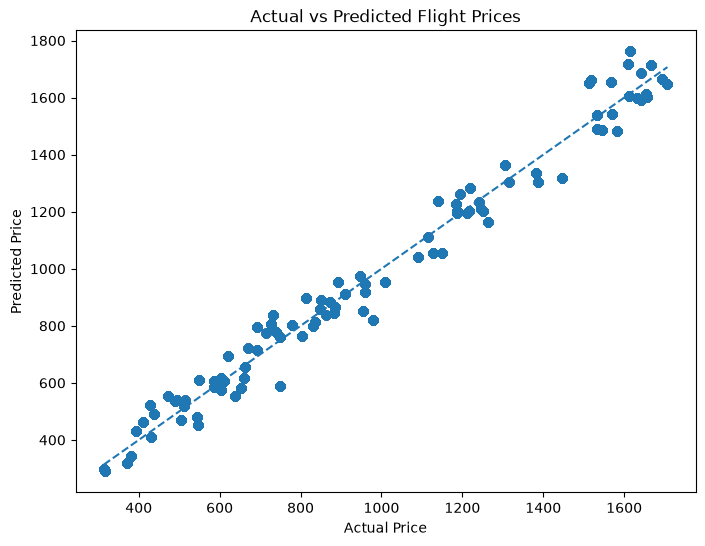

In [162]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_tuned,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Flight Prices")

plt.show()

### 5.2 Residual Analysis

Residual analysis is performed to understand the errors made by the final model.

A residual represents the difference between the actual and predicted value:

Residual = Actual Price − Predicted Price

A positive residual indicates that the model underpredicted the actual price, while a negative residual indicates that the model overpredicted the actual price.

By plotting residuals against predicted prices, we can identify systematic patterns, changes in error spread, or potential outliers that may not be visible from the evaluation metrics alone.

Ideally, residuals should be randomly distributed around zero without a clear pattern.

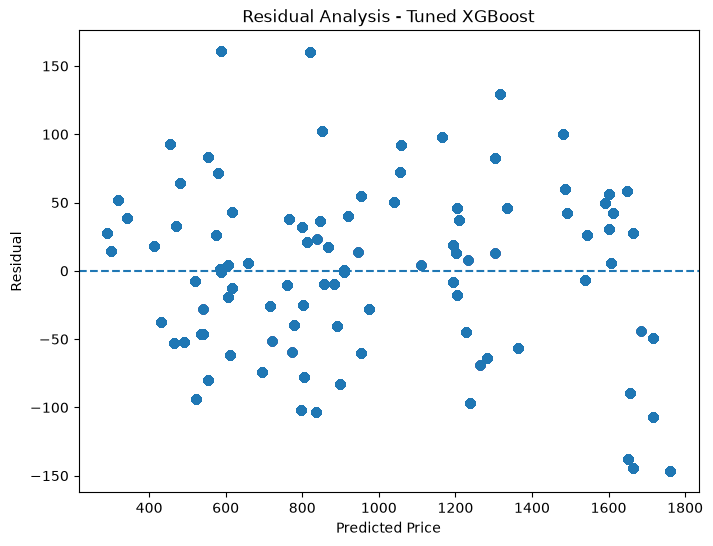

In [163]:
residuals = y_test - y_pred_tuned

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_tuned,
    residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Analysis - Tuned XGBoost")

plt.show()

### 5.2 Residual Analysis

The residual plot shows the difference between the actual and predicted flight prices.

The residuals are distributed on both sides of the zero reference line, with no strong systematic pattern or visible curve. The spread of residuals also remains reasonably consistent across the predicted price range.

A small number of observations have relatively large positive or negative residuals, indicating larger prediction errors for those cases. However, these observations appear to be isolated rather than representing a systematic issue.

Overall, the residual analysis indicates that the tuned XGBoost model does not exhibit an obvious systematic prediction bias and provides a reasonable fit to the test data.

### 5.3 Feature Importance

Feature importance is used to understand which input variables contribute most to the predictions made by the final tuned XGBoost model.

XGBoost provides built-in feature importance scores based on how the features are used within the decision trees.

A higher importance score indicates that a feature contributed more to the model's decision-making process.

This analysis helps identify the key factors associated with flight prices and improves the interpretability of the machine learning model.

It is important to note that feature importance indicates the features used most by the model, but it does not by itself explain whether a feature increases or decreases the predicted price. Direction and individual prediction effects will be examined later using SHAP analysis.

In [164]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_tuned.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
3,flightType_firstClass,0.206085
2,flightType_economic,0.173398
1,distance,0.101055
0,time,0.099627
11,from_Florianopolis (SC),0.072435
20,to_Florianopolis (SC),0.069563
24,to_Salvador (BH),0.054065
16,from_Sao Paulo (SP),0.049878
9,from_Brasilia (DF),0.035619
25,to_Sao Paulo (SP),0.030880


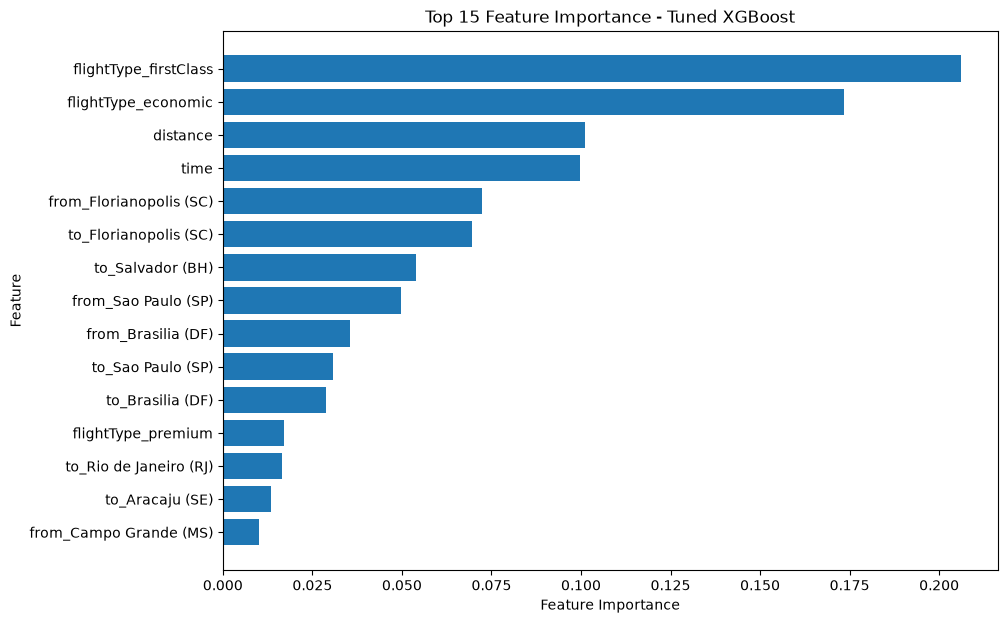

In [165]:
plt.figure(figsize=(10, 7))

top_features = feature_importance.head(15)

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance - Tuned XGBoost")

plt.show()

### 5.3 Feature Importance

The built-in feature importance of the final tuned XGBoost model was analyzed to understand which features contribute most to the model's predictions.

The results show that `flightType_firstClass` is the most important feature, followed by `flightType_economic`, `distance`, and `time`. Several origin and destination features also appear among the most influential predictors.

This indicates that flight type, journey characteristics, and route information play an important role in predicting flight prices.

However, built-in feature importance only measures the relative importance of features to the model. It does not indicate whether a feature increases or decreases the predicted price.

Therefore, SHAP analysis will be used next to understand both the magnitude and direction of individual feature contributions.

In [167]:
!pip install shap

   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   - -------------------------------------- 1.0/41.9 MB 5.8 MB/s eta 0:00:08
   - -------------------------------------- 1.6/41.9 MB 3.7 MB/s eta 0:00:11
   --- ------------------------------------ 3.4/41.9 MB 5.6 MB/s eta 0:00:07
   ---- ----------------------------------- 4.5/41.9 MB 5.6 MB/s eta 0:00:07
   ----- ---------------------------------- 5.8/41.9 MB 5.6 MB/s eta 0:00:07
   ----- ---------------------------------- 5.8/41.9 MB 5.6 MB/s eta 0:00:07
   ----- ---------------------------------- 5.8/41.9 MB 5.6 MB/s eta 0:00:07
   ----- ---------------------------------- 5.8/41.9 MB 5.6 MB/s eta 0:00:07
   ----- ---------------------------------- 5.8/41.9 MB 5.6 MB/s eta 0:00:07
   ----- ---------------------------------- 5.8/41.9 MB 5.6 MB/s eta 0:00:07
   ----- ---------------------------------- 5.8/41.9 MB 5.6 MB/s eta 0:00:07
   ----- ---------------------------------- 5.8/41.9 MB 5.6 MB/s eta 0:00:07
   ---


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


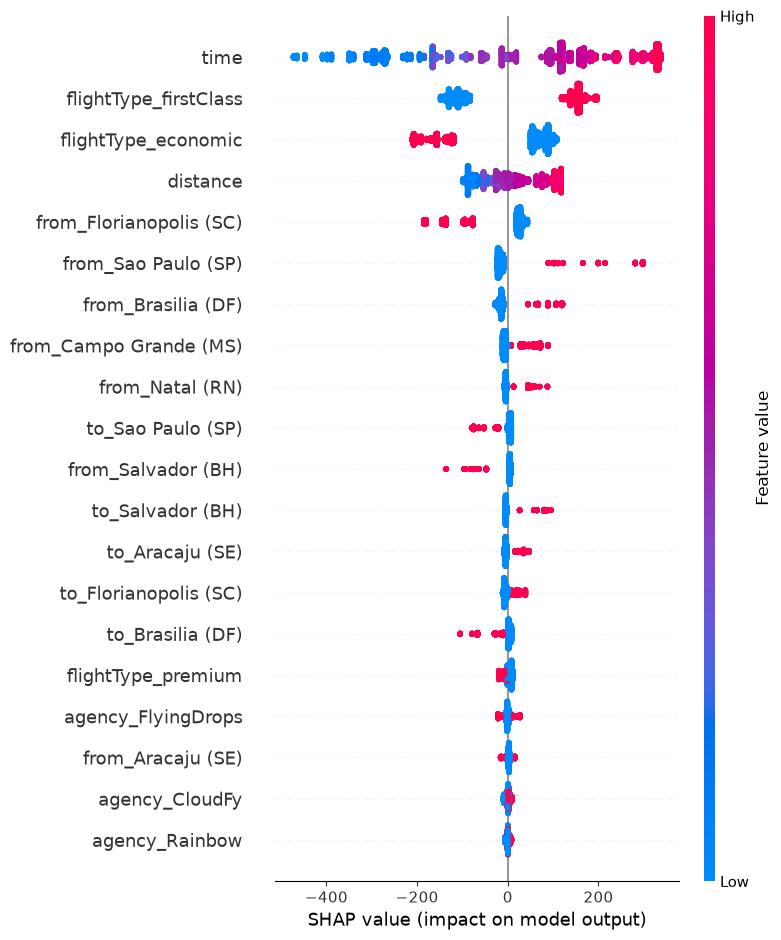

In [168]:
import shap

explainer = shap.TreeExplainer(xgb_tuned)

X_shap = X_test.sample(
    n=5000,
    random_state=42
)

shap_values = explainer(X_shap)

shap.summary_plot(
    shap_values,
    X_shap,
    show=True
)

### 5.4 SHAP Analysis

SHAP (SHapley Additive exPlanations) was used to provide a detailed interpretation of the final tuned XGBoost model.

Unlike traditional feature importance, SHAP values provide information about both the magnitude and direction of a feature's contribution to individual predictions.

For each observation:

- A positive SHAP value indicates that the feature pushes the prediction toward a higher flight price.
- A negative SHAP value indicates that the feature pushes the prediction toward a lower flight price.
- The magnitude of the SHAP value represents the strength of the feature's contribution.

A representative sample of 5,000 observations from the test set was used for SHAP visualization to reduce computational overhead while retaining a representative view of model behavior.

The SHAP summary plot provides a global overview of feature contributions and helps explain how the most influential features affect predicted flight prices.

## 6. Final Model Validation

After completing model selection, hyperparameter tuning, and model interpretation, the Optuna-tuned XGBoost Regressor is treated as the final candidate model.

The final model was evaluated on the previously untouched test dataset using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

The final test-set performance is:

- MAE: 50.58
- RMSE: 62.30
- R² Score: 0.9784

These results indicate that the model provides strong predictive performance and explains approximately 97.84% of the variation in flight prices in the test dataset.

The model also showed a strong alignment between actual and predicted prices, while residual analysis did not reveal an obvious systematic prediction pattern.

Based on the evaluation results and interpretation analysis, the Optuna-tuned XGBoost Regressor is selected as the final model for deployment.

In [169]:
final_results = pd.DataFrame({'Metrics' : ['MAE', 'RMSE', 'R2_Score'],
                              'Test Score' : [mae_tuned, rmse_tuned, r2_tuned]})

final_results

,Metrics,Test Score
0,MAE,50.576619
1,RMSE,62.304069
2,R2_Score,0.978432


## 7.3 Saving the Final Model

The Optuna-tuned XGBoost Regressor was selected as the final model based on its superior performance on the unseen test dataset.

The trained model is saved using Joblib so that it can be loaded later without retraining.

Saving the trained model allows it to be reused for future predictions and deployment.

In [174]:
import joblib
print(joblib.__version__)

1.5.3


In [175]:
import json

In [176]:
import os

print(os.getcwd())

d:\DA_Preperation\Travel-Analytics-MLOps\notebooks


In [179]:
os.makedirs("../models", exist_ok=True)

In [180]:
model_path = os.path.abspath("../models/xgb_flight_price_model.pkl")

print(model_path)

d:\DA_Preperation\Travel-Analytics-MLOps\models\xgb_flight_price_model.pkl


In [181]:
import joblib

joblib.dump(
    xgb_tuned,
    "../models/xgb_flight_price_model.pkl"
)

print(f"Model saved successfully at: {model_path}")

Model saved successfully at: d:\DA_Preperation\Travel-Analytics-MLOps\models\xgb_flight_price_model.pkl


In [182]:
os.path.exists("../models/xgb_flight_price_model.pkl")

True

In [183]:
os.listdir("../models")

['xgb_flight_price_model.pkl']

In [184]:
feature_columns = X_train.columns.tolist()

joblib.dump(
    feature_columns,
    "../models/feature_columns.pkl"
)

print("Feature columns saved successfully")

Feature columns saved successfully


In [185]:
import json

with open("../models/best_hyperparameters.json", "w") as f:
    json.dump(study.best_params, f, indent=4)

print("Best hyperparameters saved successfully")

Best hyperparameters saved successfully


In [186]:
final_metrics = {
    "MAE": float(mae_tuned),
    "RMSE": float(rmse_tuned),
    "R2_Score": float(r2_tuned)
}

with open("../models/final_model_metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=4)

print("Final metrics saved successfully")

Final metrics saved successfully


In [187]:
final_metrics = {
    "MAE": float(mae_tuned),
    "RMSE": float(rmse_tuned),
    "R2_Score": float(r2_tuned)
}

with open("../models/final_model_metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=4)

print("Final metrics saved successfully")

Final metrics saved successfully


In [188]:
metadata = {
    "model_name": "Optuna Tuned XGBoost Regressor",
    "target_variable": "price",
    "n_features": len(feature_columns),
    "train_rows": int(X_train.shape[0]),
    "test_rows": int(X_test.shape[0]),
    "optimization": "Optuna",
    "metrics": final_metrics
}

with open("../models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Metadata saved successfully")

Metadata saved successfully


In [189]:
import os

os.listdir("../models")

['best_hyperparameters.json',
 'feature_columns.pkl',
 'final_model_metrics.json',
 'model_metadata.json',
 'xgb_flight_price_model.pkl']

In [190]:
loaded_model = joblib.load(
    "../models/xgb_flight_price_model.pkl"
)

type(loaded_model)

xgboost.sklearn.XGBRegressor

In [191]:
loaded_predictions = loaded_model.predict(X_test)

loaded_rmse = np.sqrt(
    mean_squared_error(y_test, loaded_predictions)
)

loaded_r2 = r2_score(
    y_test,
    loaded_predictions
)

print(f"RMSE: {loaded_rmse:.2f}")
print(f"R2 Score: {loaded_r2:.4f}")

RMSE: 62.30
R2 Score: 0.9784
